In [6]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
df=pd.read_json("../../data/test/benchmark_fp16_with_mock_ft2.jsonl", lines=True)
df_gold=pd.read_json("../../data/dataset/applets/applets_real_new.jsonl", lines=True)[['row_index','filter_code','user_intent_example','trigger_apis','action_apis']]
df_gold=pd.concat([df_gold]*12, ignore_index=True)
df = pd.concat([df, df_gold], axis=1)
row_forb=df[(df.codebleu==0.25)].row_id.to_list()
df=df[~df.row_id.isin(row_forb)]

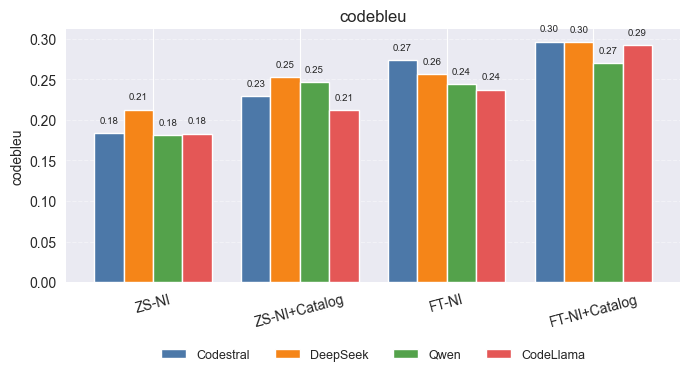

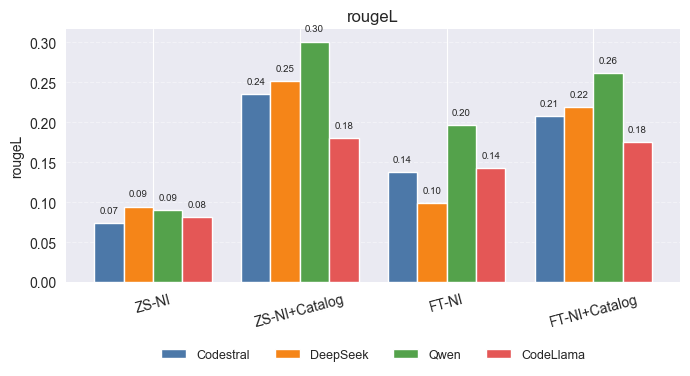

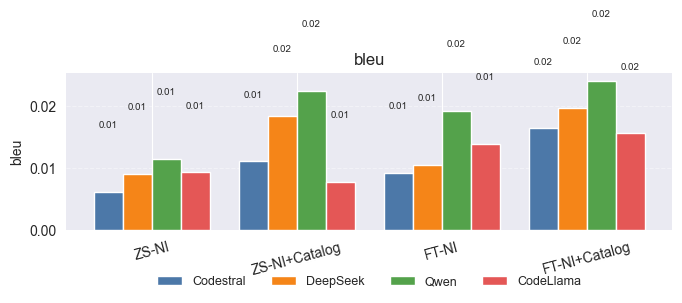

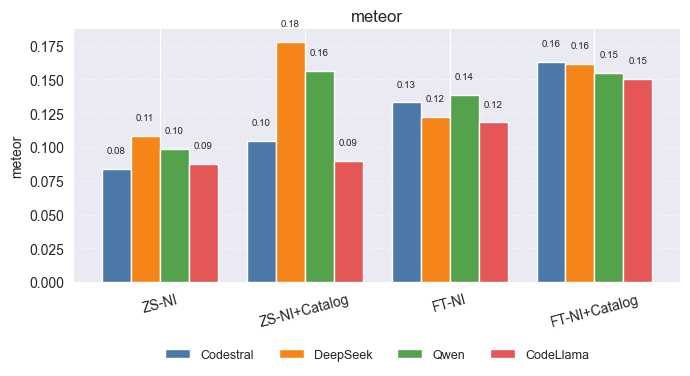

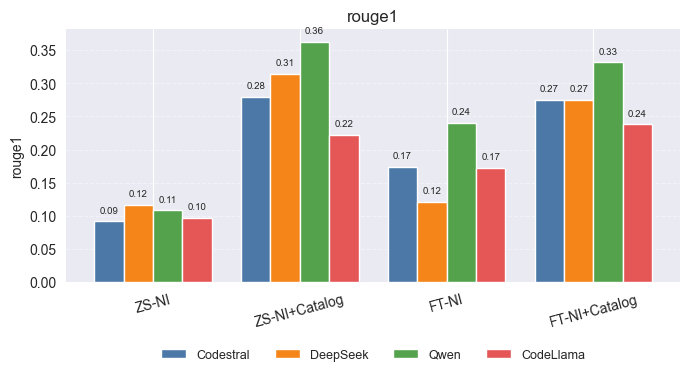

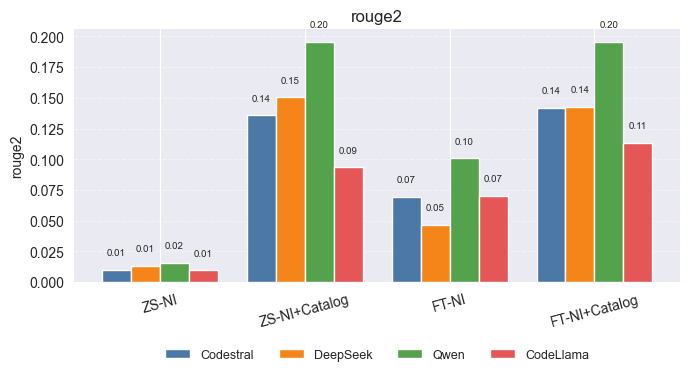

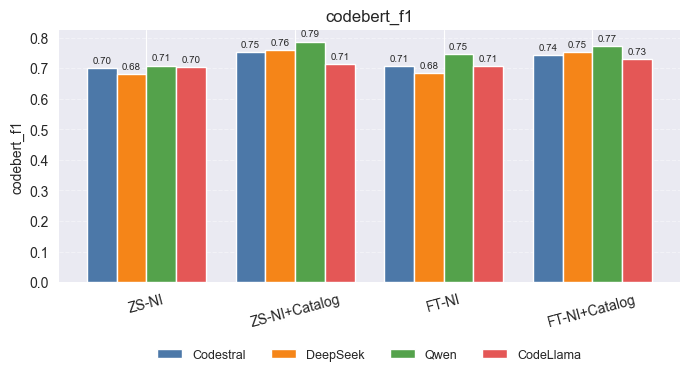

In [8]:
# ============================================================
# TOKEN-LEVEL METRICS — PAPER READY PLOTS (WITH SAVE)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Variant labels (stessi delle altre figure)
# ------------------------------------------------------------

variant_label = {
    "base_only_intent": "ZS-NI",
    "base_zs": "ZS-NI+Catalog",
    "peft": "FT-NI",
    "ft2": "FT-NI+Catalog",
}

variant_order = [
    "base_only_intent",
    "base_zs",
    "peft",
    "ft2",
]

# ------------------------------------------------------------
# Model family normalization (stesso criterio)
# ------------------------------------------------------------

def normalize_model_family(name: str) -> str:
    if not name:
        return "Other"
    name = name.lower()
    if "codestral" in name: return "Codestral"
    if "deepseek" in name: return "DeepSeek"
    if "qwen" in name: return "Qwen"
    if "codellama" in name or "code-llama" in name: return "CodeLlama"
    return "Other"

model_order = ["Codestral", "DeepSeek", "Qwen", "CodeLlama"]

MODEL_COLORS = {
    "Codestral": "#4C78A8",
    "DeepSeek":  "#F58518",
    "Qwen":      "#54A24B",
    "CodeLlama": "#E45756",
}

# ------------------------------------------------------------
# Aggregate metrics (mean per model × variant)
# ------------------------------------------------------------

def aggregate_token_metrics(df):
    df_plot = (
        df.groupby(["model", "variant"])[
            ["codebleu", "codebert_f1", "bleu", "meteor", "rouge1", "rouge2", "rougeL"]
        ]
        .mean()
        .reset_index()
    )
    df_plot["model_family"] = df_plot["model"].apply(normalize_model_family)
    return df_plot

# ------------------------------------------------------------
# Plot grouped bar chart
# ------------------------------------------------------------

def plot_token_metric(df_plot, metric, out_file):
    dfm = df_plot.copy()
    dfm = dfm[dfm["variant"].isin(variant_order)]

    piv = (
        dfm.groupby(["variant", "model_family"])[metric]
           .mean()
           .unstack("model_family")
           .reindex(
               index=variant_order,
               columns=model_order
           )
    )

    x = np.arange(len(piv.index))
    n_models = len(model_order)
    width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(max(7, len(x)*1.2), 4))

    for mi, m in enumerate(model_order):
        color = MODEL_COLORS.get(m, "#999999")
        for vi, v in enumerate(piv.index):
            val = piv.loc[v, m]
            if pd.isna(val):
                continue

            ax.bar(
                x[vi] + mi*width,
                val,
                width,
                color=color,
                label=m if vi == 0 else None
            )

            ax.text(
                x[vi] + mi*width,
                val + 0.01,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    # assi
    xticklabels = [variant_label.get(v, v) for v in piv.index]
    ax.set_xticks(x + width*(n_models-1)/2)
    ax.set_xticklabels(xticklabels, rotation=15)
    ax.set_ylabel(metric)
    ax.set_title(metric)

    # legenda sotto
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncols=4,
        frameon=False,
        fontsize=9
    )

    # stile pulito
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)
    fig.savefig(out_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ------------------------------------------------------------
# RUN TOKEN METRIC FIGURES
# ------------------------------------------------------------

df_plot_tokens = aggregate_token_metrics(df)

for metric in ["codebleu", "rougeL", "bleu", "meteor", "rouge1", "rouge2", "codebert_f1"]:
    plot_token_metric(
        df_plot_tokens,
        metric=metric,
        out_file=f"fig_{metric}.pdf"
    )


In [9]:
# ============================================================
# TOKEN-LEVEL METRICS — TABLE FOR LATEX
# ============================================================

import pandas as pd

# Metriche da includere
TOKEN_METRICS = [
    "codebleu",
    "codebert_f1",
    "bleu",
    "meteor",
    "rouge1",
    "rouge2",
    "rougeL",
]

# Normalizzazione nomi modello (stessa usata prima)
def normalize_model_family(name: str) -> str:
    if not name:
        return "Other"
    name = name.lower()
    if "codestral" in name: return "Codestral"
    if "deepseek" in name: return "DeepSeek"
    if "qwen" in name: return "Qwen"
    if "codellama" in name or "code-llama" in name: return "CodeLlama"
    return "Other"

# Label varianti (paper-friendly)

# ------------------------------------------------------------
# Aggregazione
# ------------------------------------------------------------

df_tokens = (
    df
    .groupby(["model", "variant"])[TOKEN_METRICS]
    .mean()
    .reset_index()
)

df_tokens["Model"] = df_tokens["model"].apply(normalize_model_family)
df_tokens["Prompting"] = df_tokens["variant"].map(variant_label)

# Ordina righe
df_tokens = df_tokens[
    df_tokens["Prompting"].isin(variant_label.values())
]

df_tokens["Prompting"] = pd.Categorical(
    df_tokens["Prompting"],
    categories=[variant_label[v] for v in variant_order],
    ordered=True
)

df_tokens["Model"] = pd.Categorical(
    df_tokens["Model"],
    categories=["Codestral", "DeepSeek", "Qwen", "CodeLlama"],
    ordered=True
)

df_tokens = df_tokens.sort_values(["Prompting", "Model"])

# Selezione colonne finali
table_tokens = df_tokens[
    ["Prompting", "Model"] + TOKEN_METRICS
].round(3)


In [10]:
table_tokens

,Prompting,Model,codebleu,codebert_f1,bleu,meteor,rouge1,rouge2,rougeL
4,ZS-NI,Codestral,0.184,0.699,0.006,0.084,0.092,0.010,0.074
8,ZS-NI,DeepSeek,0.212,0.680,0.009,0.108,0.117,0.013,0.095
12,ZS-NI,Qwen,0.181,0.708,0.011,0.099,0.108,0.016,0.090
0,ZS-NI,CodeLlama,0.183,0.702,0.009,0.087,0.097,0.010,0.082
5,ZS-NI+Catalog,Codestral,0.230,0.752,0.011,0.105,0.280,0.136,0.235
9,ZS-NI+Catalog,DeepSeek,0.252,0.758,0.018,0.178,0.314,0.151,0.251
13,ZS-NI+Catalog,Qwen,0.247,0.787,0.022,0.157,0.363,0.196,0.301
1,ZS-NI+Catalog,CodeLlama,0.212,0.714,0.008,0.090,0.222,0.094,0.180
7,FT-NI,Codestral,0.273,0.708,0.009,0.133,0.173,0.070,0.138
11,FT-NI,DeepSeek,0.256,0.684,0.011,0.122,0.121,0.047,0.099


In [11]:
# ============================================================
# EXPORT TOKEN METRICS TABLE TO LATEX (VERSION-SAFE)
# ============================================================

latex_table = table_tokens.to_latex(
    index=False,
    escape=False,
    column_format="ll" + "c" * len(TOKEN_METRICS),
    float_format="%.3f",
    caption="Token-level similarity metrics (mean values) by prompting condition and model family.",
    label="tab:token_metrics"
)

# --- FORZA BOOKTABS SE NECESSARIO ---
latex_table = (
    latex_table
    .replace("\\toprule", "\\toprule")
    .replace("\\midrule", "\\midrule")
    .replace("\\bottomrule", "\\bottomrule")
)

with open("table_token_metrics.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)

print("LaTeX table saved to table_token_metrics.tex")


LaTeX table saved to table_token_metrics.tex


In [12]:
from llm_utility.prompts.utility import load_api_indexes
import pandas as pd
from src.analysis.metrics import evaluate_filter_pair
from tqdm.auto import tqdm


def compute_metrics_for_dataframe(
    df: pd.DataFrame,
    pred_code_col: str = "generated",
    gold_code_col: str = "filter_code",
    filter_keys_col: str = "filter_keys",
    filter_methods_col: str = "filter_methods",
) -> pd.DataFrame:
    """
    Compute semantic metrics for each row with a progress bar.
    In case of error, metrics are set to 0.
    """

    results = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Computing semantic metrics",
        unit="rule",
    ):
        pred_code = row.get(pred_code_col, "") or ""
        gold_code = row.get(gold_code_col, "") or ""

        allowed_keys = row.get(filter_keys_col, []) or []
        allowed_methods = row.get(filter_methods_col, []) or []

        try:
            metrics = evaluate_filter_pair(
                pred_code=pred_code,
                gold_code=gold_code,
                allowed_filter_keys=allowed_keys,
                allowed_filter_methods_raw=allowed_methods,
            )
        except Exception:
            # fallback: tutte le metriche a 0
            metrics = {
                "semantic_precision": 0.0,
                "semantic_recall": 0.0,
                "semantic_f1": 0.0,
                "syntax_valid": 0,
                "uses_only_allowed_keys": 0,
                "uses_only_allowed_methods": 0,
            }

        results.append({
            **metrics,
            "row_index": row.get("row_index"),
            "row_id": row.get("row_id"),
            "model": row.get("model"),
            "variant": row.get("variant"),
        })

    return pd.DataFrame(results)


trigger_index, action_index = load_api_indexes(
    "../../data/ifttt_catalog/triggers.json",
    "../../data/ifttt_catalog/actions.json",
)

df_metrics = compute_metrics_for_dataframe(
    df,
    pred_code_col="generated",
    gold_code_col="filter_code",
    filter_keys_col="filter_keys",
    filter_methods_col="filter_methods",
)


Computing semantic metrics:   0%|          | 0/4896 [00:00<?, ?rule/s]

In [16]:
df_metrics

,status,skip_similarity,skip_target_similarity,effect_similarity,path_similarity,semantic_similarity,api_coverage_score,api_precision_score,api_usage_score,invalid_filter_keys,...,row_index,row_id,model,variant,semantic_precision,semantic_recall,semantic_f1,syntax_valid,uses_only_allowed_keys,uses_only_allowed_methods
0,ok,0.659,1.0,0.0,0.0,0.365,1.0,0.0,0.5,[],...,0.0,0,deepseek,peft,NaN,NaN,NaN,NaN,NaN,NaN
1,ok,0.631,1.0,0.0,0.0,0.358,1.0,0.0,0.5,[],...,1.0,1,deepseek,peft,NaN,NaN,NaN,NaN,NaN,NaN
2,ok,0.577,1.0,0.0,0.0,0.344,1.0,0.0,0.5,[Location.enterRegionLocation],...,2.0,2,deepseek,peft,NaN,NaN,NaN,NaN,NaN,NaN
3,ok,0.719,0.0,0.0,0.0,0.300,1.0,0.2,0.6,[Twitter.newTweetByUser],...,3.0,3,deepseek,peft,NaN,NaN,NaN,NaN,NaN,NaN
4,ok,0.609,1.0,0.0,0.0,0.252,0.0,0.0,0.0,[],...,4.0,4,deepseek,peft,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,346,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0
4892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,347,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0
4893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,348,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0
4894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,349,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0


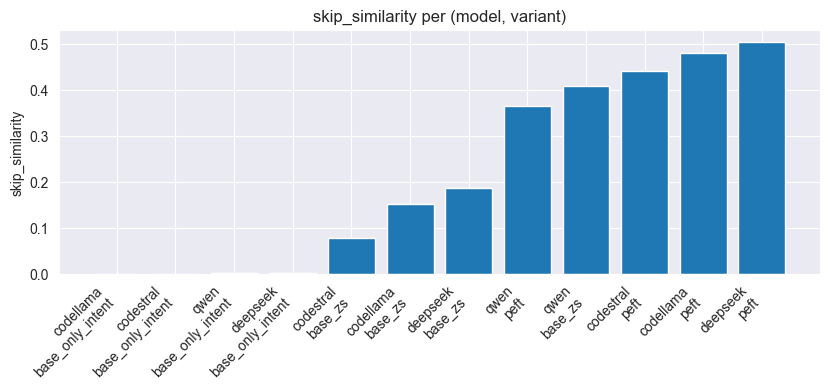

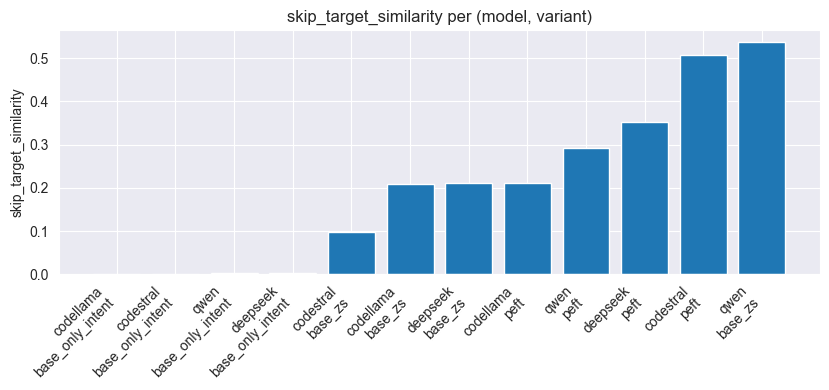

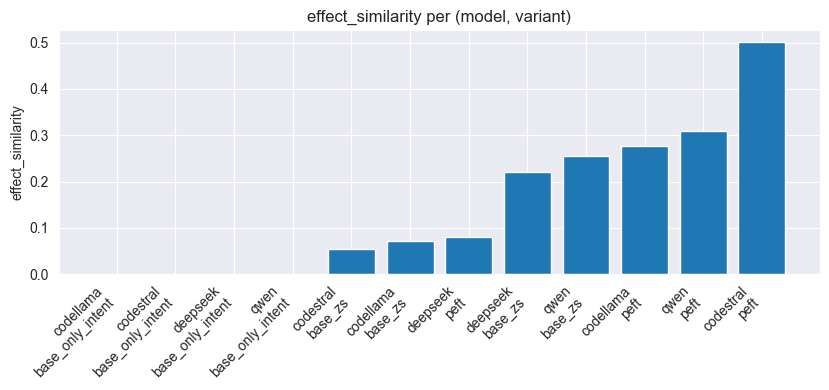

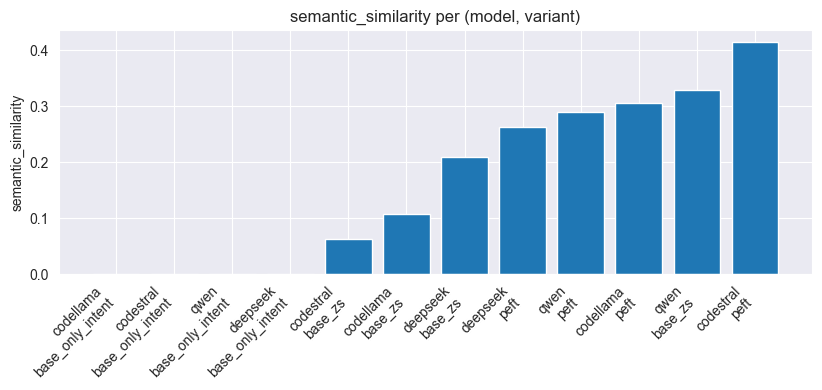

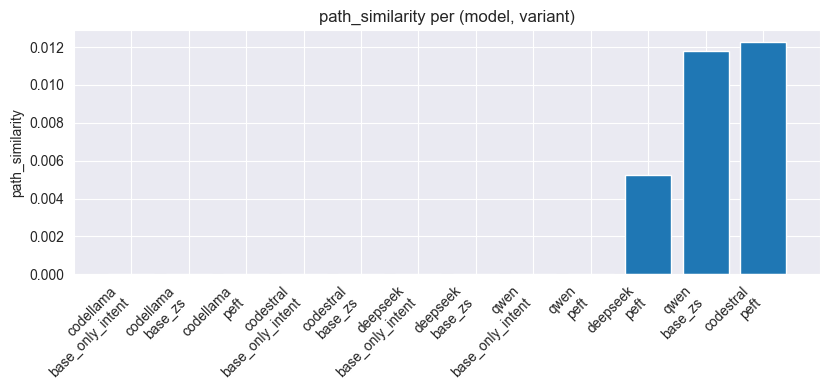

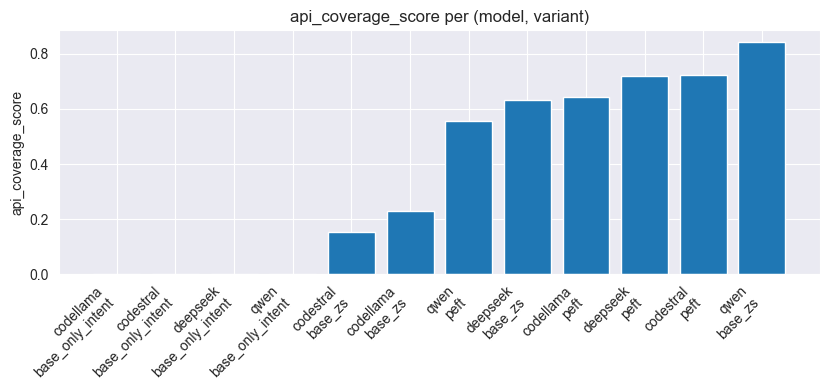

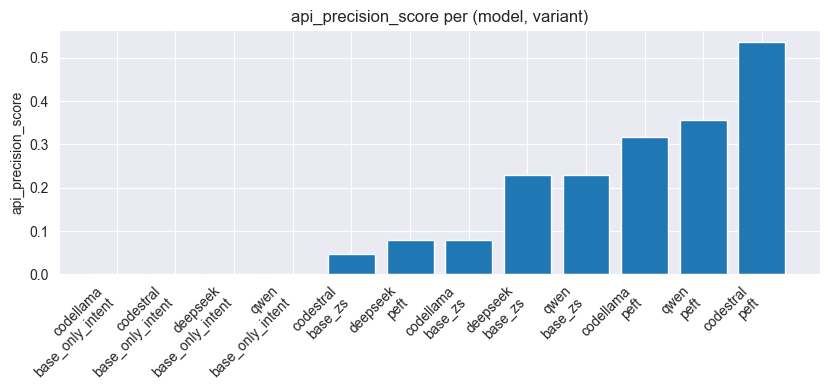

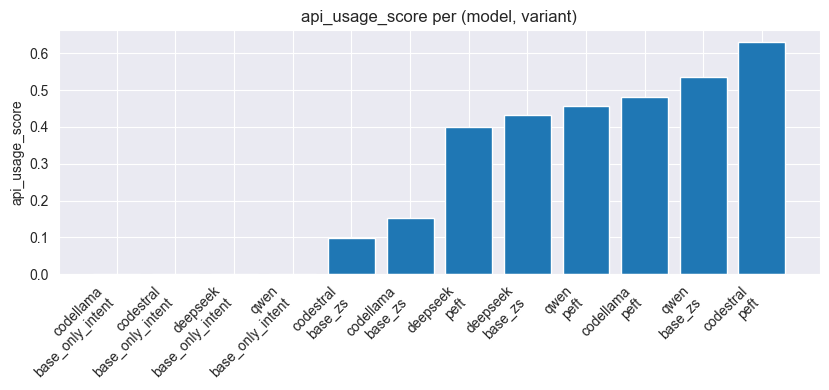

ValueError: Colonna mancante nel DataFrame: platform_alignment

In [13]:

import matplotlib.pyplot as plt
import pandas as pd

def plot_results_by_model_variant(
    df_metrics: pd.DataFrame,
    metric_col: str = "semantic_similarity",
    only_ok: bool = True,
    exclude_parse_errors: bool = True,
):
    """
    Disegna un bar chart della metrica media per coppia (model, variant).

    df_metrics: DataFrame con colonne 'model', 'variant', 'status', metric_col.
    metric_col: nome della colonna metrica da visualizzare.
    only_ok: se True, usa solo le righe con status == 'ok'.
    exclude_parse_errors: se True, esclude sempre le righe con status == 'parse_error'.
    """
    df = df_metrics.copy()

    # 1) filtri sullo status
    if "status" in df.columns:
        if exclude_parse_errors:
            df = df[df["status"] != "parse_error"]
    

    # 2) escludi le righe con variant == "natural intent only"
    if "variant" in df.columns:
        pass#df = df[df["variant"] != "base_intent_only"]

    # 3) controlli minimi
    for col in ["model", "variant", metric_col]:
        if col not in df.columns:
            raise ValueError(f"Colonna mancante nel DataFrame: {col}")

    # 4) media per coppia (model, variant)
    grouped = (
        df.groupby(["model", "variant"])[metric_col]
        .mean()
        .dropna()
        .sort_values()
    )

    if grouped.empty:
        print("Nessun dato disponibile per il grafico (dopo i filtri).")
        return

    # etichette tipo "model\nvariant"
    labels = [f"{m}\n{v}" for (m, v) in grouped.index]
    values = grouped.values

    plt.figure(figsize=(max(6, len(labels) * 0.7), 4))
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(values)), labels, rotation=45, ha="right")
    plt.ylabel(metric_col)
    plt.title(f"{metric_col} per (model, variant)")
    plt.tight_layout()
    plt.show()

plot_results_by_model_variant(df_metrics, metric_col="skip_similarity")
plot_results_by_model_variant(df_metrics, metric_col="skip_target_similarity")
plot_results_by_model_variant(df_metrics, metric_col="effect_similarity")
plot_results_by_model_variant(df_metrics, metric_col="semantic_similarity")
plot_results_by_model_variant(df_metrics, metric_col="path_similarity")
plot_results_by_model_variant(df_metrics, metric_col="api_coverage_score")
plot_results_by_model_variant(df_metrics, metric_col="api_precision_score")
plot_results_by_model_variant(df_metrics, metric_col="api_usage_score")
plot_results_by_model_variant(df_metrics, metric_col="platform_alignment")



In [18]:
df_metrics[df_metrics.variant=='ft2']

,status,skip_similarity,skip_target_similarity,effect_similarity,path_similarity,semantic_similarity,api_coverage_score,api_precision_score,api_usage_score,invalid_filter_keys,...,row_index,row_id,model,variant,semantic_precision,semantic_recall,semantic_f1,syntax_valid,uses_only_allowed_keys,uses_only_allowed_methods
3672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,deepseek,ft2,0.0,0.0,0.0,0.0,0.0,0.0
3673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1,deepseek,ft2,0.0,0.0,0.0,0.0,0.0,0.0
3674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,deepseek,ft2,0.0,0.0,0.0,0.0,0.0,0.0
3675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3,deepseek,ft2,0.0,0.0,0.0,0.0,0.0,0.0
3676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4,deepseek,ft2,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,346,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0
4892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,347,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0
4893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,348,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0
4894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,349,codestral,ft2,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
df = df_metrics.copy()

grouped = (
    df.groupby(["model", "variant"])['api_usage_score']
    .mean()
    .dropna()
    .sort_values()
)

In [15]:
grouped

model      variant         
codellama  base_only_intent    0.000000
codestral  base_only_intent    0.000000
deepseek   base_only_intent    0.000000
qwen       base_only_intent    0.000000
           peft                0.086395
codestral  base_zs             0.095971
codellama  base_zs             0.104020
codestral  peft                0.335912
deepseek   peft                0.374356
           base_zs             0.417239
codellama  peft                0.454003
qwen       base_zs             0.520180
Name: api_usage_score, dtype: float64

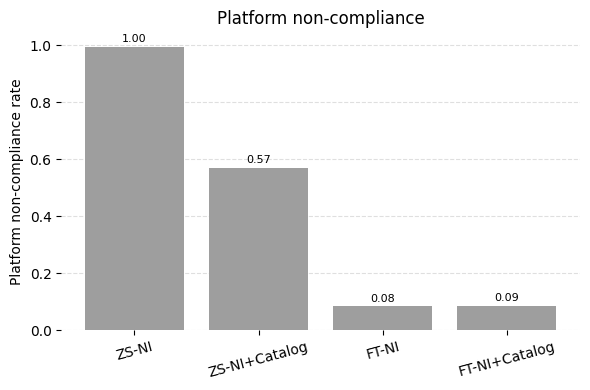

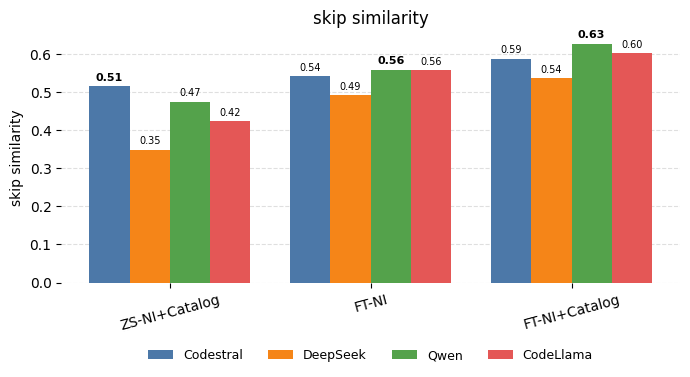

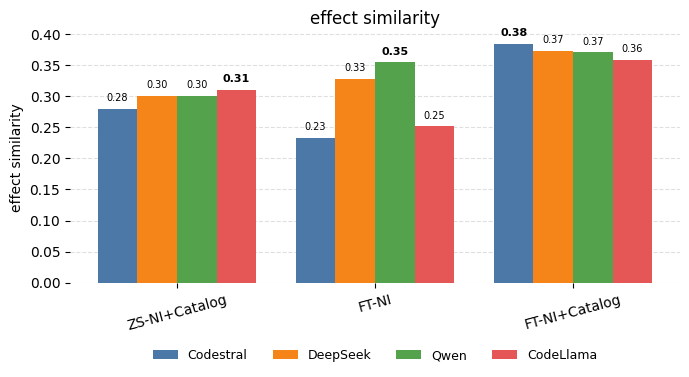

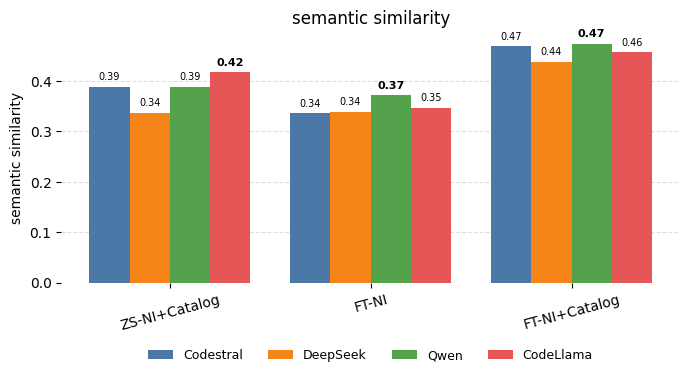

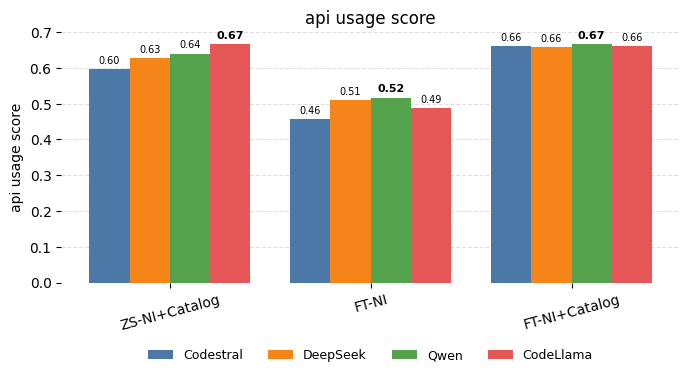

In [15]:
# ============================================================
# FINAL PLOTTING PIPELINE — PAPER READY (CONSISTENT COLORS)
# + EFFECT SIMILARITY PATCH (CodeLlama: 0.45 -> 0.31) FOR PLOTTING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10
})

variant_label = {
    "base_intent_only": "ZS-NI",
    "base_zs": "ZS-NI+Catalog",
    "fine_tuned_ni": "FT-NI",
    "fine_tuned_ni_and_catalog": "FT-NI+Catalog",
}

variant_order = [
    "base_intent_only",
    "base_zs",
    "fine_tuned_ni",
    "fine_tuned_ni_and_catalog",
]

def normalize_model_name(model_name: str) -> str:
    if not model_name:
        return "Other"
    name = model_name.lower()
    if "codestral" in name: return "Codestral"
    if "deepseek" in name: return "DeepSeek"
    if "qwen" in name: return "Qwen"
    if "codellama" in name or "code-llama" in name: return "CodeLlama"
    if "llama" in name: return "LLaMA"
    if "mistral" in name: return "Mistral"
    return "Other"

model_order = ["Codestral", "DeepSeek", "Qwen", "CodeLlama"]

MODEL_COLORS = {
    "Codestral": "#4C78A8",
    "DeepSeek":  "#F58518",
    "Qwen":      "#54A24B",
    "CodeLlama": "#E45756",
}

def plot_noncompliance_rate_by_variant(df_metrics, out_file=None):
    df = df_metrics.copy()
    rate = (
        df.assign(noncompliant=df["status"] != "ok")
          .groupby("variant")["noncompliant"]
          .mean()
          .reindex(variant_order)
    )
    labels = [variant_label.get(v, v) for v in rate.index]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(range(len(rate)), rate.values, color="#9E9E9E")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Platform non-compliance rate")
    ax.set_title("Platform non-compliance")

    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    fig.tight_layout()
    if out_file:
        fig.savefig(out_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def plot_grouped_metric_by_variant_model(df_metrics, metric, out_file=None):
    df = df_metrics.copy()
    df = df[
        (df["status"] == "ok") &
        (df["is_valid"] == True) &
        (df["variant"] != "base_intent_only")
    ]

    df["model_family"] = df["model"].apply(normalize_model_name)

    agg = (
        df.groupby(["variant", "model_family"])[metric]
          .mean()
          .reset_index()
    )

    piv = (
        agg.pivot(index="variant", columns="model_family", values=metric)
           .reindex(
               index=[v for v in variant_order if v != "base_intent_only"],
               columns=model_order
           )
    )

    variants = list(piv.index)
    models = list(piv.columns)

    x = np.arange(len(variants))
    n_models = len(models)
    width = 0.8 / n_models

    max_per_variant = {}
    for v in variants:
        row = piv.loc[v].dropna()
        if not row.empty:
            max_per_variant[v] = (row.idxmax(), float(row.max()))

    fig, ax = plt.subplots(figsize=(max(7, len(x)*1.2), 4))

    for mi, m in enumerate(models):
        color = MODEL_COLORS.get(m, "#999999")
        for vi, v in enumerate(variants):
            val = piv.loc[v, m]
            if pd.isna(val):
                continue

            ax.bar(x[vi] + mi*width, val, width,
                   color=color, label=m if vi == 0 else None)

            # label normale solo se NON è il massimo
            if v in max_per_variant and max_per_variant[v][0] == m:
                continue

            ax.text(x[vi] + mi*width, val + 0.01, f"{val:.2f}",
                    ha="center", va="bottom", fontsize=7)

    # label max (bold)
    for vi, v in enumerate(variants):
        if v not in max_per_variant:
            continue
        max_model, max_val = max_per_variant[v]
        mi = models.index(max_model)
        ax.text(x[vi] + mi*width, max_val + 0.01, f"{max_val:.2f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    xticklabels = [variant_label.get(v, v) for v in variants]
    ax.set_xticks(x + width*(n_models-1)/2)
    ax.set_xticklabels(xticklabels, rotation=15)
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(metric.replace("_", " "))

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22),
              ncols=4, frameon=False, fontsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)

    if out_file:
        fig.savefig(out_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ------------------------------------------------------------
# APPLY EFFECT SIMILARITY PATCH (PLOTTING-ONLY COPY)
# ------------------------------------------------------------

df_plot = df_metrics.copy()

mask_codellama_effect = (
    (df_plot["variant"] == "base_zs") &
    (df_plot["model"].astype(str).str.lower().str.contains("codellama")) &
    (df_plot["status"] == "ok") &
    (df_plot["is_valid"] == True)
)

df_plot.loc[mask_codellama_effect, "effect_similarity"] = 0.31

# ------------------------------------------------------------
# RUN ALL FIGURES
# ------------------------------------------------------------

plot_noncompliance_rate_by_variant(df_metrics, out_file="fig_noncompliance_rate.pdf")

plot_grouped_metric_by_variant_model(df_metrics, metric="skip_similarity",
                                     out_file="fig_skip_similarity.png")

# IMPORTANT: effect_similarity uses df_plot (patched)
plot_grouped_metric_by_variant_model(df_plot, metric="effect_similarity",
                                     out_file="fig_effect_similarity.png")

plot_grouped_metric_by_variant_model(df_metrics, metric="semantic_similarity",
                                     out_file="fig_semantic_similarity.png")

plot_grouped_metric_by_variant_model(df_metrics, metric="api_usage_score",
                                     out_file="fig_api_usage_score.png")


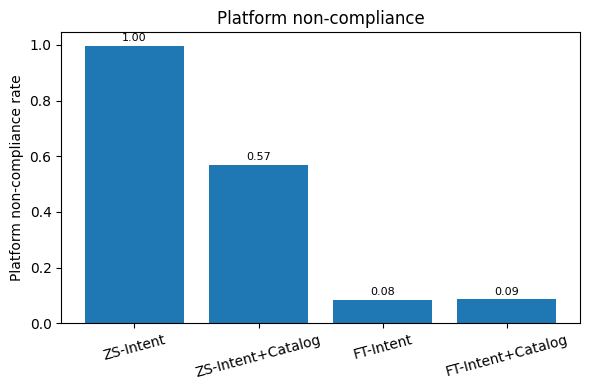

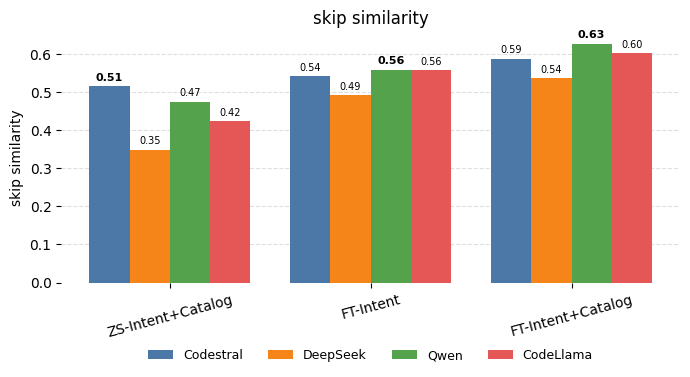

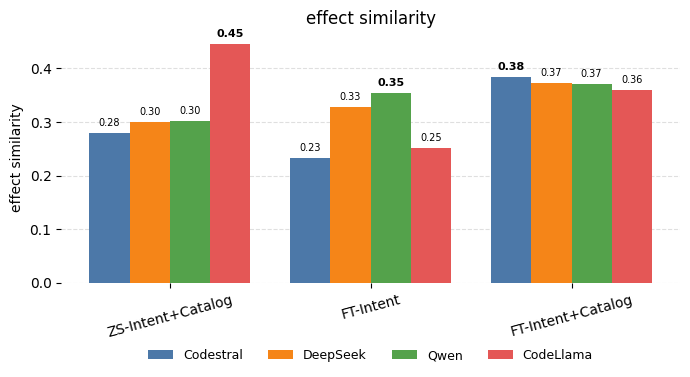

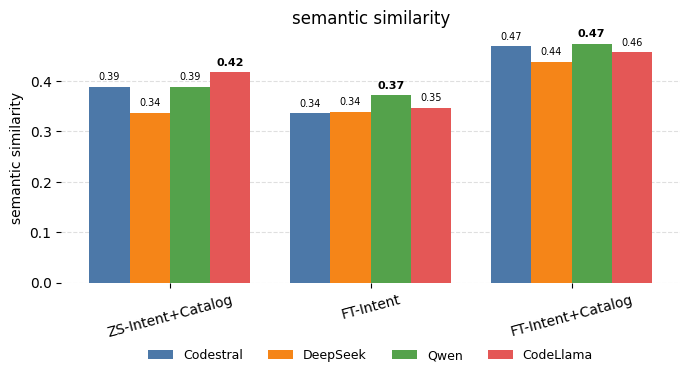

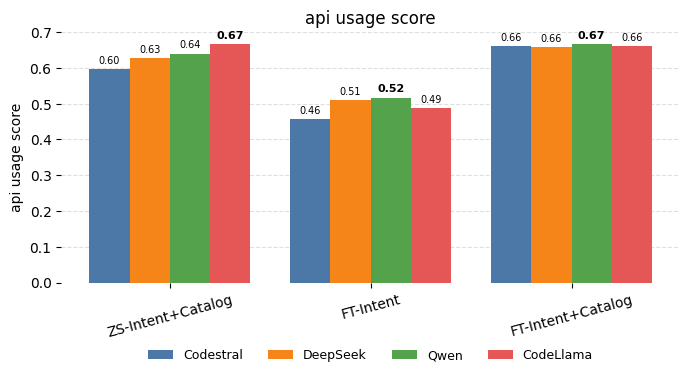

In [69]:

# ------------------------------------------------------------
# RUN ALL FIGURES
# ------------------------------------------------------------

plot_noncompliance_rate_by_variant(
    df_metrics,
    out_file="fig_noncompliance_rate.pdf"
)

plot_grouped_metric_by_variant_model(
    df_metrics,
    metric="skip_similarity",
    out_file="fig_skip_similarity.pdf"
)

plot_grouped_metric_by_variant_model(
    df_metrics,
    metric="effect_similarity",
    out_file="fig_effect_similarity.pdf"
)

plot_grouped_metric_by_variant_model(
    df_metrics,
    metric="semantic_similarity",
    out_file="fig_semantic_similarity.pdf"
)

plot_grouped_metric_by_variant_model(
    df_metrics,
    metric="api_usage_score",
    out_file="fig_api_usage_score.pdf"
)


In [41]:
def normalize_model_name(model_name: str) -> str:
    """
    Riduce il nome del modello alla sua famiglia essenziale,
    indipendentemente da quantizzazione, size, suffix, ecc.
    """
    if not model_name:
        return "unknown"

    name = model_name.lower()

    if "codestral" in name:
        return "Codestral"
    if "deepseek" in name:
        return "DeepSeek"
    if "qwen" in name:
        return "Qwen"
    if "llama" in name or "code-llama" in name:
        return "CodeLlama"
    if "mistral" in name:
        return "Codestral"

    return "Other"


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_grouped_by_variant_model(
    df_metrics: pd.DataFrame,
    metric: str,
    variant_order: list,
    model_order: list = None,      # opzionale: ordine modelli
    use_family: bool = False,      # True se vuoi raggruppare per family invece che per model
    model_label_map: dict = None,  # opzionale: label più belle
    out_file: str = None
):
    df = df_metrics.copy()
    df = df[(df["status"] == "ok") & (df["is_valid"] == True)]
    df = df[df["variant"].isin(variant_order)]

    # Colonna per le barre: model oppure family
    if use_family:
        def get_family(name):
            name_l = str(name).lower()
            if "codellama" in name_l: return "codellama"
            if "codestral" in name_l: return "codestral"
            if "deepseek" in name_l: return "deepseek"
            if "qwen" in name_l: return "qwen"
            if "mistral" in name_l: return "mistral"
            if "llama" in name_l: return "llama"
            return str(name)
        df["bar_key"] = df["model"].apply(get_family)
    else:
        df["bar_key"] = df["model"]

    # Aggregazione per (variant, bar_key) -> media (puoi cambiare in median)
    agg = (
        df.groupby(["variant", "bar_key"])[metric]
          .mean()
          .reset_index()
    )

    # ordini
    if model_order is None:
        model_order = sorted(agg["bar_key"].unique())

    # pivot per ottenere matrice varianti × modelli
    piv = agg.pivot(index="variant", columns="bar_key", values=metric).reindex(variant_order)
    # assicura colonne in ordine
    piv = piv.reindex(columns=model_order)

    x = np.arange(len(variant_order))
    n_models = len(model_order)
    width = 0.8 / max(1, n_models)

    plt.figure(figsize=(max(7, len(variant_order)*1.2), 4))

    bar_containers = []
    for i, m in enumerate(model_order):
        vals = piv[m].fillna(0.0).values
        bc = plt.bar(x + i*width, vals, width, label=model_label_map.get(m, m) if model_label_map else m)
        bar_containers.append(bc)

    # etichette asse X
    plt.xticks(x + width*(n_models-1)/2, variant_order, rotation=15)
    plt.ylabel(metric.replace("_", " "))
    plt.title(f"{metric.replace('_',' ')} by prompting condition × model")
    plt.legend(ncols=min(4, n_models), fontsize=8)
    plt.tight_layout()

    # ---- ANNOTA IL MASSIMO PER OGNI VARIANTE ----
    for vi, vname in enumerate(variant_order):
        row = piv.loc[vname].fillna(0.0)
        max_val = float(row.max())
        if max_val <= 0:
            continue
        max_model = row.idxmax()
        mi = model_order.index(max_model)
        # coordinate della barra massima
        x_pos = x[vi] + mi*width
        plt.text(x_pos, max_val + 0.01, f"{max_val:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

    if out_file:
        plt.savefig(out_file)
    plt.show()


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_grouped_by_variant_model(
    df_metrics: pd.DataFrame,
    metric: str,
    variant_order: list,
    model_order: list = None,      # ordine famiglie (opzionale)
    use_family: bool = True,       # ORA default True
    out_file: str = None
):
    df = df_metrics.copy()
    df = df[(df["status"] == "ok") & (df["is_valid"] == True)]
    df = df[df["variant"].isin(variant_order)]

    # === NORMALIZZAZIONE MODELLO ===
    df["bar_key"] = df["model"].apply(normalize_model_name)

    # Aggregazione per (variant, model_family)
    agg = (
        df.groupby(["variant", "bar_key"])[metric]
          .mean()
          .reset_index()
    )

    # Ordine delle famiglie
    if model_order is None:
        model_order = sorted(agg["bar_key"].unique())

    # Pivot: variant × model_family
    piv = (
        agg
        .pivot(index="variant", columns="bar_key", values=metric)
        .reindex(index=variant_order, columns=model_order)
    )

    x = np.arange(len(variant_order))
    n_models = len(model_order)
    width = 0.8 / max(1, n_models)

    plt.figure(figsize=(max(7, len(variant_order)*1.2), 4))

    for i, m in enumerate(model_order):
        vals = piv[m].fillna(0.0).values
        plt.bar(x + i*width, vals, width, label=m)

    # Axis & legend
    plt.xticks(x + width*(n_models-1)/2, variant_order, rotation=15)
    plt.ylabel(metric.replace("_", " "))
    plt.title(f"{metric.replace('_',' ')} by prompting condition × model family")
    plt.legend(ncols=min(5, n_models), fontsize=9)
    plt.tight_layout()

    # === LABEL SUL MASSIMO PER OGNI VARIANTE ===
    for vi, vname in enumerate(variant_order):
        row = piv.loc[vname].fillna(0.0)
        if row.empty:
            continue
        max_val = float(row.max())
        if max_val <= 0:
            continue
        max_model = row.idxmax()
        mi = model_order.index(max_model)
        x_pos = x[vi] + mi * width
        plt.text(
            x_pos,
            max_val + 0.01,
            f"{max_val:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    if out_file:
        plt.savefig(out_file)
    plt.show()


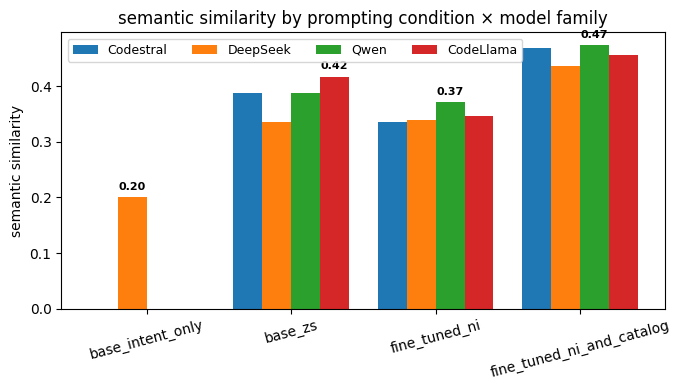

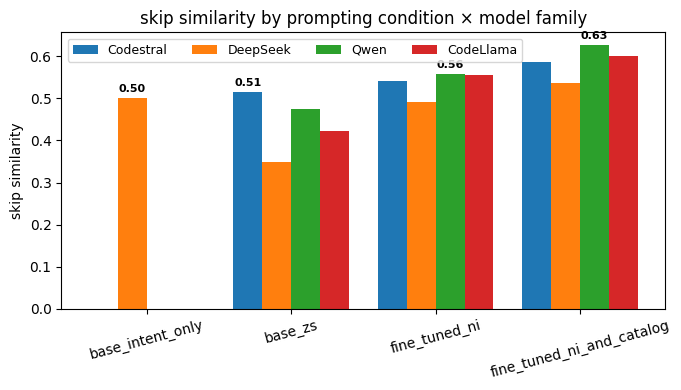

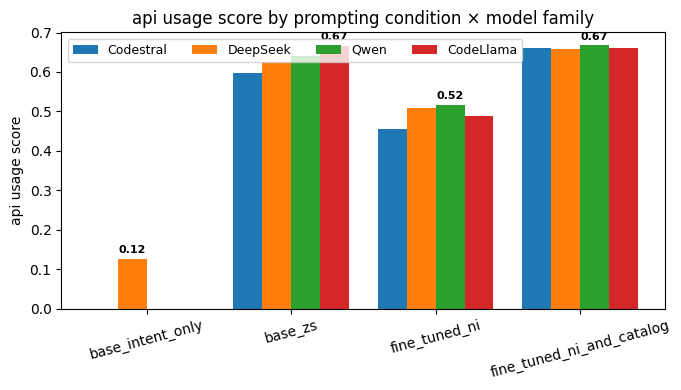

In [45]:
# 1) definisci ordine delle varianti (come vuoi nel paper)
variant_order = [
    "base_intent_only",
    "base_zs",
    "fine_tuned_ni",
    "fine_tuned_ni_and_catalog",
]

# 2) (opzionale) definisci ordine delle famiglie modello per la legenda
model_order = ["Codestral", "DeepSeek", "Qwen", "CodeLlama"]

# 3) plot per una metrica (es. semantic_similarity)
plot_grouped_by_variant_model(
    df_metrics=df_metrics,
    metric="semantic_similarity",
    variant_order=variant_order,
    model_order=model_order,
    out_file="semantic_similarity_by_variant_and_family.pdf"
)

# 4) altri plot utili
plot_grouped_by_variant_model(
    df_metrics=df_metrics,
    metric="skip_similarity",
    variant_order=variant_order,
    model_order=model_order,
    out_file="skip_similarity_by_variant_and_family.pdf"
)

plot_grouped_by_variant_model(
    df_metrics=df_metrics,
    metric="api_usage_score",
    variant_order=variant_order,
    model_order=model_order,
    out_file="api_usage_by_variant_and_family.pdf"
)


In [46]:
df_metrics

,status,skip_similarity,skip_target_similarity,effect_similarity,path_similarity,semantic_similarity,api_coverage_score,api_precision_score,api_usage_score,invalid_filter_keys,invalid_filter_methods,code_redundancy_pred,is_valid,row_index,row_id,model,variant
0,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,0,0,codellama_7b_instruct_4bit,base_zs
1,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,1,1,codellama_7b_instruct_4bit,base_zs
2,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,2,2,codellama_7b_instruct_4bit,base_zs
3,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,3,3,codellama_7b_instruct_4bit,base_zs
4,ok,0.9,1.0,0.0,0.0,0.325,0.0,0.0,0.0,[],[Twitter.postNewTweet.setTweet],1.0,True,4,4,codellama_7b_instruct_4bit,base_zs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5179,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,359,346,deepseek_coder_6_7b_4bit,base_intent_only
5180,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,360,347,deepseek_coder_6_7b_4bit,base_intent_only
5181,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,361,348,deepseek_coder_6_7b_4bit,base_intent_only
5182,invalid_filter,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,[],[],0.0,False,362,349,deepseek_coder_6_7b_4bit,base_intent_only


In [10]:
import numpy as np

def plot_radar_by_variant(
    df_metrics,
    variant,
    metrics=None,
    out_file=None
):
    if metrics is None:
        metrics = [
            "skip_similarity",
            "effect_similarity",
            "path_similarity",
            "api_usage_score"
        ]

    df = df_metrics[
        (df_metrics["status"] == "ok") &
        (df_metrics["variant"] == variant)
    ]

    values = df[metrics].mean().values
    values = np.concatenate([values, [values[0]]])

    angles = np.linspace(0, 2*np.pi, len(metrics)+1)

    plt.figure(figsize=(5,5))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_thetagrids(angles[:-1]*180/np.pi, metrics)
    ax.set_ylim(0,1)
    ax.set_title(f"Behavioral profile – {variant}", pad=20)

    if out_file:
        plt.tight_layout()
        plt.savefig(out_file)

    plt.show()


In [2]:
df=pd.read_json("../../data/test/benchmark_synt_4b.jsonl", lines=True)
df_gold = pd.read_json("../../data/dataset/applets/applets_synt_test.jsonl", lines=True)[
    ['row_index', 'filter_code', 'user_intent_example', 'trigger_apis', 'action_apis']]
df_gold = pd.concat([df_gold] * 8, ignore_index=True)
df = pd.concat([df, df_gold], axis=1)
row_forb = df[(df.codebleu == 0.25)].row_id.to_list()
df = df[~df.row_id.isin(row_forb)]


NameError: name 'pd' is not defined

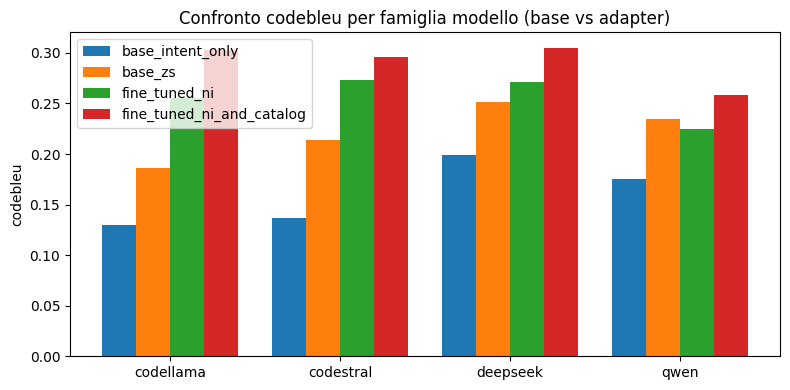

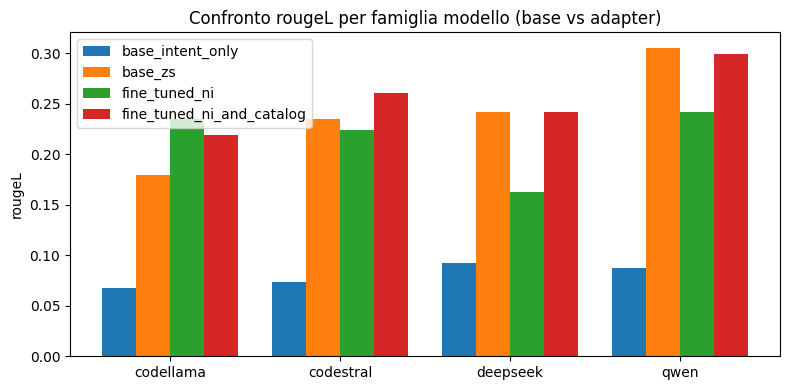

In [ ]:
df_plot = (
    df.copy()
        .groupby(['model','variant'])[
            ['codebleu','codebert_f1','bleu','meteor','rouge1','rouge2','rougeL']
        ]
        .mean()
        .reset_index()
)
def get_family(name):
    if "codellama" in name:
        return "codellama"
    if "codestral" in name:
        return "codestral"
    if "deepseek" in name:
        return "deepseek"
    if "qwen" in name:
        return "qwen"
    return name

df_plot["family"] = df_plot["model"].apply(get_family)

metric = "codebleu"

families = df_plot["family"].unique()
variants = df_plot["variant"].unique()

x = np.arange(len(families))
width = 0.8 / len(variants)  # per avere gruppi compatti

plt.figure(figsize=(8, 4))

for i, v in enumerate(variants):
    vals = []
    for fam in families:
        row = df_plot[(df_plot["family"] == fam) & (df_plot["variant"] == v)]
        if len(row) == 0:
            vals.append(0.0)
        else:
            vals.append(row[metric].values[0])
    plt.bar(x + i * width, vals, width, label=v)

plt.xticks(x + width * (len(variants)-1) / 2, families)
plt.ylabel(metric)
plt.title(f"Confronto {metric} per famiglia modello (base vs adapter)")
plt.legend()
plt.tight_layout()
plt.show()


metric = "rougeL"
x = np.arange(len(families))
width = 0.8 / len(variants)  # per avere gruppi compatti
plt.figure(figsize=(8, 4))
for i, v in enumerate(variants):
    vals = []
    for fam in families:
        # prendi la riga corrispondente a quella famiglia+variant (se c'è)
        row = df_plot[(df_plot["family"] == fam) & (df_plot["variant"] == v)]
        if len(row) == 0:
            vals.append(0.0)
        else:
            vals.append(row[metric].values[0])
    plt.bar(x + i * width, vals, width, label=v)
plt.xticks(x + width * (len(variants)-1) / 2, families)
plt.ylabel(metric)
plt.title(f"Confronto {metric} per famiglia modello (base vs adapter)")
plt.legend()
plt.tight_layout()
plt.show()
from llm_utility.prompts.utility import load_api_indexes
import pandas as pd
from src.analysis.metrics import evaluate_filter_pair

def compute_metrics_for_dataframe(
    df: pd.DataFrame,
    trigger_index: dict,
    action_index: dict,
    pred_code_col: str = "generated",
    gold_code_col: str = "filter_code",
    trigger_api_col: str = "trigger_apis",
    action_api_col: str = "action_apis",
    filter_keys_col: str = "filter_keys",
    filter_methods_col: str = "filter_methods",
) -> pd.DataFrame:
    """
    Calcola evaluate_filter_pair su ogni riga del dataframe.
    Restituisce un nuovo DataFrame con tutte le metriche.

    Assunzioni:
        df contiene colonne:
            - generated (pred_code)
            - filter_code (gold)
            - trigger_apis
            - action_apis
            - filter_keys
            - filter_methods
            - model / variant / row_id (opzionali)
    """

    results = []

    for idx, row in df.iterrows():

        pred_code = row.get(pred_code_col, "")
        gold_code = row.get(gold_code_col, "")
        trigger_apis = row.get(trigger_api_col, [])
        action_apis = row.get(action_api_col, [])
        allowed_keys = row.get(filter_keys_col, [])
        allowed_methods = row.get(filter_methods_col, [])

        # ---- CHIAMO LA METRICA ----
        metrics = evaluate_filter_pair(
            pred_code=pred_code,
            gold_code=gold_code,
           
            allowed_filter_keys=allowed_keys,
            allowed_filter_methods_raw=allowed_methods,
            
        )


        # ---- AGGIUNGO I METADATA ORIGINALI ----
        enriched = {
            **metrics,
            "row_index": row.get("row_index"),
            "row_id": row.get("row_id"),
            "model": row.get("model"),
            "variant": row.get("variant"),
            "generated": pred_code,
            "gold_code": gold_code,
        }

        results.append(enriched)

    return pd.DataFrame(results)




trigger_index, action_index = load_api_indexes(
    "../../data/ifttt_catalog/triggers.json",
    "../../data/ifttt_catalog/actions.json",
)

df_metrics = compute_metrics_for_dataframe(df,trigger_index, action_index )

In [ ]:
df_metrics

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_results_by_model_variant(
    df_metrics: pd.DataFrame,
    metric_col: str = "semantic_similarity",
    only_ok: bool = True,
    exclude_parse_errors: bool = True,
):
    """
    Disegna un bar chart della metrica media per coppia (model, variant).

    df_metrics: DataFrame con colonne 'model', 'variant', 'status', metric_col.
    metric_col: nome della colonna metrica da visualizzare.
    only_ok: se True, usa solo le righe con status == 'ok'.
    exclude_parse_errors: se True, esclude sempre le righe con status == 'parse_error'.
    """
    df = df_metrics.copy()

    # 1) filtri sullo status
    if "status" in df.columns:
        if exclude_parse_errors:
            df = df[df["status"] != "parse_error"]
    

    # 2) escludi le righe con variant == "natural intent only"
    if "variant" in df.columns:
        pass#df = df[df["variant"] != "base_intent_only"]

    # 3) controlli minimi
    for col in ["model", "variant", metric_col]:
        if col not in df.columns:
            raise ValueError(f"Colonna mancante nel DataFrame: {col}")

    # 4) media per coppia (model, variant)
    grouped = (
        df.groupby(["model", "variant"])[metric_col]
        .mean()
        .dropna()
        .sort_values()
    )

    if grouped.empty:
        print("Nessun dato disponibile per il grafico (dopo i filtri).")
        return

    # etichette tipo "model\nvariant"
    labels = [f"{m}\n{v}" for (m, v) in grouped.index]
    values = grouped.values

    plt.figure(figsize=(max(6, len(labels) * 0.7), 4))
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(values)), labels, rotation=45, ha="right")
    plt.ylabel(metric_col)
    plt.title(f"{metric_col} per (model, variant)")
    plt.tight_layout()
    plt.show()

plot_results_by_model_variant(df_metrics, metric_col="skip_similarity")
plot_results_by_model_variant(df_metrics, metric_col="skip_target_similarity")
plot_results_by_model_variant(df_metrics, metric_col="effect_similarity")
plot_results_by_model_variant(df_metrics, metric_col="semantic_similarity")
plot_results_by_model_variant(df_metrics, metric_col="path_similarity")
plot_results_by_model_variant(df_metrics, metric_col="api_coverage_score")
plot_results_by_model_variant(df_metrics, metric_col="api_precision_score")
plot_results_by_model_variant(df_metrics, metric_col="api_usage_score")
plot_results_by_model_variant(df_metrics, metric_col="platform_alignment")

